PHAN 5: TEST MO HINH - PHAT HIEN XAM NHAP MANG

1. KIEM TRA VA DOC DU LIEU TEST
--------------------------------------------------
Tat ca cac file can thiet deu co san

X_test shape: (758, 19)
y_test shape: (758,)
So luong dac trung: 19

Phan phoi nhan trong tap test:
   - Normal (0): 422 mau
   - Attack (1): 336 mau
   - Ty le tan cong: 44.33%

2. TAI MO HINH DA HUAN LUYEN
Da tai mo hinh: RandomForestClassifier
Da tai preprocessor components

3. DU DOAN TREN TAP TEST

Thoi gian inference: 0.0791 giay
So luong mau du doan: 758
Toc do: 9583 mau/giay

4. DANH GIA TOAN DIEN TREN TAP TEST

CAC CHI SO CO BAN:
--------------------------------------------------
   Accuracy:  0.8826 (88.26%)
   Precision: 0.9960 (99.60%)
   Recall:    0.7381 (73.81%)
   F1-Score:  0.8479 (84.79%)
   ROC-AUC:   0.8679 (86.79%)

5. KIEM TRA RO RI DU LIEU

Ket qua tu qua trinh training:
              Model  Train_Acc  Val_Acc   Val_F1  Val_AUC  Val_Recall
Logistic Regression   0.736129 0.701453 0.677143 0.794652 

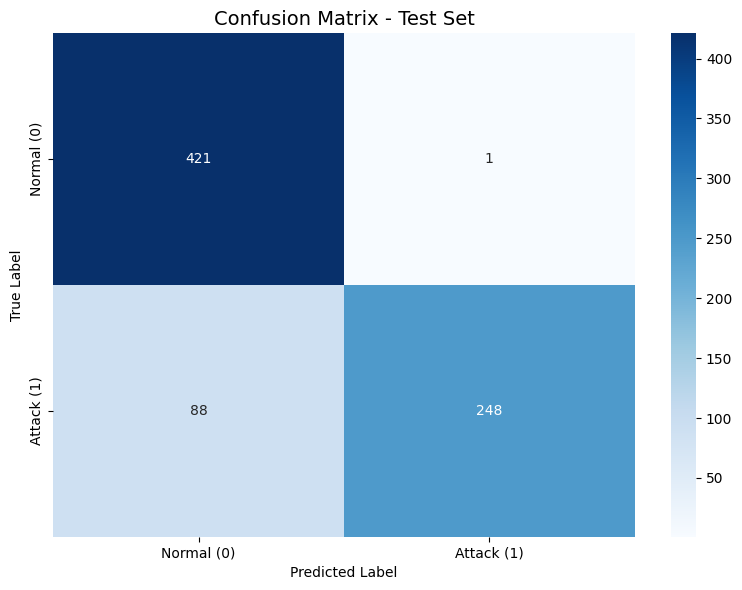


Da luu confusion matrix: ../models/test_confusion_matrix.png

7. CLASSIFICATION REPORT

Bao cao phan loai chi tiet:
--------------------------------------------------
              precision    recall  f1-score   support

  Normal (0)       0.83      1.00      0.90       422
  Attack (1)       1.00      0.74      0.85       336

    accuracy                           0.88       758
   macro avg       0.91      0.87      0.88       758
weighted avg       0.90      0.88      0.88       758


8. ROC CURVE


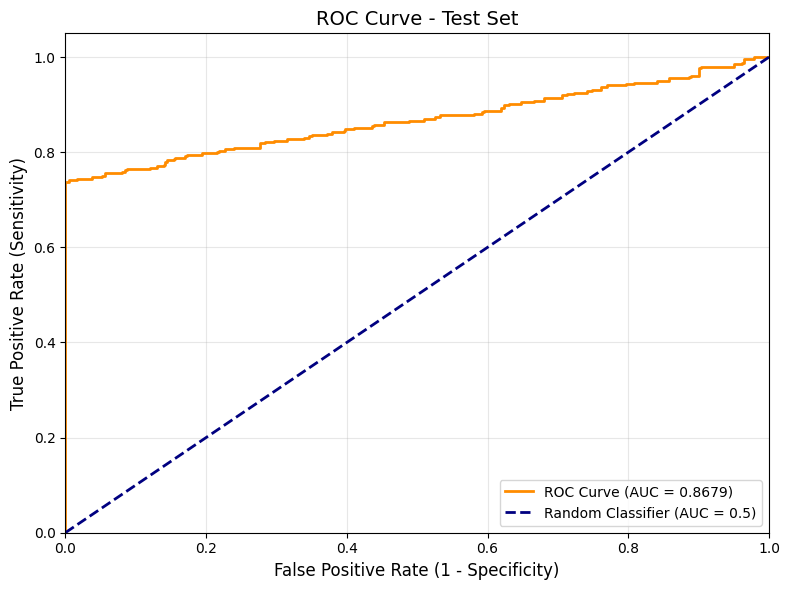


Dien tich duoi duong cong ROC (AUC): 0.8679

Nguong toi uu theo Youden's J: 0.7505
   -> Tai nguong nay: TPR = 0.7381, FPR = 0.0000

Da luu ROC curve: ../models/test_roc_curve.png

9. PHAN TICH SAI SO (ERROR ANALYSIS)

Thong ke sai so:
   - False Positives (Canh bao sai): 1 / 422 = 0.24%
   - False Negatives (Bo sot tan cong): 88 / 336 = 26.19%

NHAN XET:
   -> Mo hinh co xu huong BO SOT TAN CONG (FN cao hon FP)
   -> Co the dieu chinh threshold xuong thap hon de tang recall

10. THU NGHIEM VOI CAC NGUONG KHAC NHAU

Anh huong cua nguong (threshold) den ket qua:
-------------------------------------------------------------------------------------
Threshold    Precision    Recall       F1-Score     FP       FN      
-------------------------------------------------------------------------------------
0.3          0.8793       0.7589       0.8147       35       81      
0.4          0.9728       0.7440       0.8432       7        86      
0.5          0.9960       0.7381       0.8479    

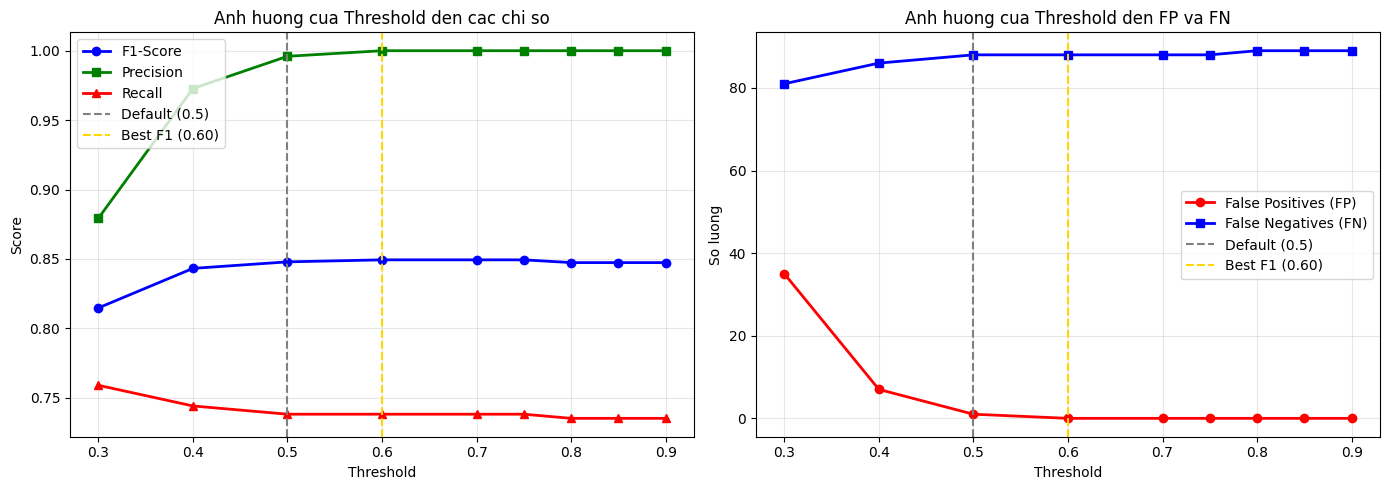


Da luu bieu do phan tich threshold: ../models/threshold_analysis.png

GOI Y CHON NGUONG:
   - Nguong 0.50 (mac dinh): F1=0.8479, FP=1, FN=88
   - Nguong 0.60 (toi uu F1): F1=0.8493, FP=0, FN=88

   Nguong mac dinh (0.5) KHONG phai toi uu!
   -> Nen su dung nguong 0.60 de dat F1-Score tot nhat

11. KET LUAN VA DANH GIA TONG THE

KET QUA TEST MO HINH - DANH GIA: KHA

1. THONG TIN TAP TEST:
   - So luong mau: 758
   - Ty le tan cong: 44.33%

2. HIEU SUAT TREN TEST:
   - F1-Score:  0.8479 (84.79%)
   - ROC-AUC:   0.8679 (86.79%)
   - Accuracy:  0.8826 (88.26%)
   - Precision: 0.9960 (99.60%)
   - Recall:    0.7381 (73.81%)

3. MA TRAN NHAM LAN:
   - True Negative  (TN): 421
   - False Positive (FP): 1
   - False Negative (FN): 88
   - True Positive  (TP): 248

4. DANH GIA CHUNG:
   - Mo hinh dat yeu cau ve do chinh xac
   - Can cai thien them truoc khi trien khai


12. LUU KET QUA TEST
Da luu ket qua test: ../models/test_results.csv
Da luu confusion matrix: ../models/test_confusion_matrix

In [ ]:
# -*- coding: utf-8 -*-
"""PHAN 5: TEST MO HINH - KIEM TRA TREN TAP TEST CHUA NHIN THAY"""

import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler


class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}
    
    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            cols = X.columns
        else:
            cols = [f'feature_{i}' for i in range(X.shape[1])]
        
        for i, col in enumerate(cols):
            col_data = X[:, i] if not hasattr(X, 'columns') else X[col]
            Q1 = np.quantile(col_data, 0.25)
            Q3 = np.quantile(col_data, 0.75)
            IQR = Q3 - Q1
            self.lower_bounds_[col] = Q1 - self.factor * IQR
            self.upper_bounds_[col] = Q3 + self.factor * IQR
        return self
    
    def transform(self, X):
        X_copy = X.copy() if hasattr(X, 'copy') else np.array(X)
        if hasattr(X_copy, 'columns'):
            for col in X_copy.columns:
                X_copy[col] = X_copy[col].clip(self.lower_bounds_[col], self.upper_bounds_[col])
        else:
            for i, col in enumerate(self.lower_bounds_.keys()):
                X_copy[:, i] = np.clip(X_copy[:, i], self.lower_bounds_[col], self.upper_bounds_[col])
        return X_copy

class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=1.0):
        self.skew_threshold = skew_threshold
        self.log_cols_ = []
        self.log_col_indices_ = []
    
    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            cols = X.columns
        else:
            cols = [f'feature_{i}' for i in range(X.shape[1])]
        
        for i, col in enumerate(cols):
            col_data = X[:, i] if not hasattr(X, 'columns') else X[col]
            skew_val = pd.Series(col_data).skew()
            if skew_val > self.skew_threshold:
                self.log_cols_.append(col)
                self.log_col_indices_.append(i)
        return self
    
    def transform(self, X):
        X_copy = X.copy() if hasattr(X, 'copy') else np.array(X)
        
        if hasattr(X_copy, 'columns'):
            for col in self.log_cols_:
                X_copy[f'{col}_log'] = np.log1p(X_copy[col])
            X_copy = X_copy.drop(columns=self.log_cols_)
        else:
            log_values = []
            keep_indices = []
            for i in range(X_copy.shape[1]):
                if i in self.log_col_indices_:
                    log_values.append(np.log1p(X_copy[:, i:i+1]))
                else:
                    keep_indices.append(i)
            if log_values:
                X_copy = np.hstack([X_copy[:, keep_indices]] + log_values)
        
        return X_copy

class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = StandardScaler()
        self.feature_names_in_ = None
    
    def fit(self, X, y=None):
        self.scaler.fit(X)
        self.feature_names_in_ = X.columns if hasattr(X, 'columns') else None
        return self
    
    def transform(self, X):
        scaled = self.scaler.transform(X)
        if self.feature_names_in_ is not None:
            return pd.DataFrame(scaled, columns=self.feature_names_in_)
        return scaled

print("="*80)
print("PHAN 5: TEST MO HINH - PHAT HIEN XAM NHAP MANG")
print("="*80)

# =============================================================================
# 1. KIEM TRA VA DOC DU LIEU TEST
# =============================================================================

print("\n1. KIEM TRA VA DOC DU LIEU TEST")
print("-"*50)

required_files = [
    "../data_processed/X_test_processed.pkl",
    "../data_processed/y_test.pkl",
    "../models/final_model.pkl",
    "../models/feature_names.pkl"
]

missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    print(f"THIEU FILE: {missing_files}")
    print("Vui long chay PHAN 3 va PHAN 4 truoc!")
    exit()
else:
    print("Tat ca cac file can thiet deu co san")

X_test = joblib.load("../data_processed/X_test_processed.pkl")
y_test = joblib.load("../data_processed/y_test.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"So luong dac trung: {len(feature_names)}")

print(f"\nPhan phoi nhan trong tap test:")
print(f"   - Normal (0): {(y_test == 0).sum():,} mau")
print(f"   - Attack (1): {(y_test == 1).sum():,} mau")
print(f"   - Ty le tan cong: {y_test.mean():.2%}")

# =============================================================================
# 2. TAI MO HINH DA HUAN LUYEN
# =============================================================================

print("\n" + "="*80)
print("2. TAI MO HINH DA HUAN LUYEN")
print("="*80)

final_model = joblib.load("../models/final_model.pkl")
print(f"Da tai mo hinh: {type(final_model).__name__}")

try:
    preprocessor_components = joblib.load("../models/preprocessor_components.pkl")
    print("Da tai preprocessor components")
except:
    print("Khong the tai preprocessor components (khong anh huong den du doan)")

# =============================================================================
# 3. DU DOAN TREN TAP TEST
# =============================================================================

print("\n" + "="*80)
print("3. DU DOAN TREN TAP TEST")
print("="*80)

start_time = time.time()
y_pred = final_model.predict(X_test)

if hasattr(final_model, 'predict_proba'):
    y_proba = final_model.predict_proba(X_test)[:, 1]
    has_proba = True
else:
    y_proba = None
    has_proba = False

inference_time = time.time() - start_time

print(f"\nThoi gian inference: {inference_time:.4f} giay")
print(f"So luong mau du doan: {len(y_pred)}")
print(f"Toc do: {len(y_pred)/inference_time:.0f} mau/giay")

# =============================================================================
# 4. DANH GIA TOAN DIEN TREN TAP TEST
# =============================================================================

print("\n" + "="*80)
print("4. DANH GIA TOAN DIEN TREN TAP TEST")
print("="*80)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nCAC CHI SO CO BAN:")
print("-"*50)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

if has_proba:
    auc = roc_auc_score(y_test, y_proba)
    print(f"   ROC-AUC:   {auc:.4f} ({auc*100:.2f}%)")

# =============================================================================
# 5. SO SANH VOI KET QUA TRAIN/VAL (PHAT HIEN RO RI)
# =============================================================================

print("\n" + "="*80)
print("5. KIEM TRA RO RI DU LIEU")
print("="*80)

try:
    training_results = pd.read_csv("../models/training_results.csv")
    print("\nKet qua tu qua trinh training:")
    print(training_results.to_string(index=False))
    
    rf_result = training_results[training_results['Model'] == 'Random Forest']
    if len(rf_result) > 0:
        val_f1 = rf_result['Val_F1'].values[0]
        print(f"\nSO SANH:")
        print(f"   - Validation F1-Score: {val_f1:.4f}")
        print(f"   - Test F1-Score:       {f1:.4f}")
        print(f"   - Chenh lech:          {abs(val_f1 - f1):.4f}")
        
        if abs(val_f1 - f1) > 0.05:
            print("\n   CANH BAO: Chenh lech > 0.05, co the co dau hieu:")
            print("       1. Overfitting (mo hinh qua phuc tap)")
            print("       2. Ro ri du lieu (data leakage)")
            print("       3. Phan phoi du lieu test khac train/val")
        else:
            print("\n   Ket qua on dinh, KHONG co dau hieu ro ri du lieu!")
    else:
        print("\nKhong tim thay ket qua Random Forest trong file training_results.csv")
        
except FileNotFoundError:
    print("\nKhong tim thay file training_results.csv, bo qua buoc so sanh")

# =============================================================================
# 6. CONFUSION MATRIX
# =============================================================================

print("\n" + "="*80)
print("6. MA TRAN NHAM LAN (CONFUSION MATRIX)")
print("="*80)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nGia tri chi tiet:")
print("-"*40)
print(f"   True Negative  (TN): {tn:,}  -> Du doan dung Normal")
print(f"   False Positive (FP): {fp:,}  -> Du doan Attack nhung thuc te Normal (Canh bao sai)")
print(f"   False Negative (FN): {fn:,}  -> Du doan Normal nhung thuc te Attack (Bo sot tan cong)")
print(f"   True Positive  (TP): {tp:,}  -> Du doan dung Attack")

if (tn + fp) > 0:
    fpr = fp / (tn + fp)
    print(f"\n   False Positive Rate (FPR): {fpr:.4f} ({fpr*100:.2f}%)")
if (tp + fn) > 0:
    fnr = fn / (tp + fn)
    print(f"   False Negative Rate (FNR): {fnr:.4f} ({fnr*100:.2f}%)")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'])
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../models/test_confusion_matrix.png', dpi=150)
plt.show()

print("\nDa luu confusion matrix: ../models/test_confusion_matrix.png")

# =============================================================================
# 7. CLASSIFICATION REPORT
# =============================================================================

print("\n" + "="*80)
print("7. CLASSIFICATION REPORT")
print("="*80)

print("\nBao cao phan loai chi tiet:")
print("-"*50)
print(classification_report(y_test, y_pred, 
                            target_names=['Normal (0)', 'Attack (1)']))

# =============================================================================
# 8. ROC CURVE
# =============================================================================

if has_proba:
    print("\n" + "="*80)
    print("8. ROC CURVE")
    print("="*80)
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title(f'ROC Curve - Test Set', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../models/test_roc_curve.png', dpi=150)
    plt.show()
    
    print(f"\nDien tich duoi duong cong ROC (AUC): {auc:.4f}")
    
    youden_j = tpr - fpr
    best_threshold = thresholds[np.argmax(youden_j)]
    print(f"\nNguong toi uu theo Youden's J: {best_threshold:.4f}")
    print(f"   -> Tai nguong nay: TPR = {tpr[np.argmax(youden_j)]:.4f}, FPR = {fpr[np.argmax(youden_j)]:.4f}")
    
    print("\nDa luu ROC curve: ../models/test_roc_curve.png")

# =============================================================================
# 9. PHAN TICH SAI SO (ERROR ANALYSIS)
# =============================================================================

print("\n" + "="*80)
print("9. PHAN TICH SAI SO (ERROR ANALYSIS)")
print("="*80)

print(f"\nThong ke sai so:")
print(f"   - False Positives (Canh bao sai): {fp:,} / {(y_test == 0).sum():,} = {fp/(y_test == 0).sum()*100:.2f}%")
print(f"   - False Negatives (Bo sot tan cong): {fn:,} / {(y_test == 1).sum():,} = {fn/(y_test == 1).sum()*100:.2f}%")

if fp > 0 or fn > 0:
    print(f"\nNHAN XET:")
    if fp > fn:
        print(f"   -> Mo hinh co xu huong CANH BAO SAI (FP cao hon FN)")
        print(f"   -> Co the dieu chinh threshold len cao hon de giam FP")
    elif fn > fp:
        print(f"   -> Mo hinh co xu huong BO SOT TAN CONG (FN cao hon FP)")
        print(f"   -> Co the dieu chinh threshold xuong thap hon de tang recall")
    else:
        print(f"   -> Mo hinh can bang giua FP va FN")

# =============================================================================
# 10. THU NGHIEM VOI CAC NGUONG KHAC NHAU
# =============================================================================

if has_proba:
    print("\n" + "="*80)
    print("10. THU NGHIEM VOI CAC NGUONG KHAC NHAU")
    print("="*80)
    
    thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
    
    print("\nAnh huong cua nguong (threshold) den ket qua:")
    print("-"*85)
    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'FP':<8} {'FN':<8}")
    print("-"*85)
    
    threshold_results = []
    
    for thresh in thresholds_to_test:
        y_pred_custom = (y_proba >= thresh).astype(int)
        prec = precision_score(y_test, y_pred_custom)
        rec = recall_score(y_test, y_pred_custom)
        f1_custom = f1_score(y_test, y_pred_custom)
        cm_custom = confusion_matrix(y_test, y_pred_custom)
        fp_custom = cm_custom[0, 1]
        fn_custom = cm_custom[1, 0]
        
        threshold_results.append({
            'threshold': thresh,
            'precision': prec,
            'recall': rec,
            'f1': f1_custom,
            'fp': fp_custom,
            'fn': fn_custom
        })
        
        marker = " <- DEFAULT" if thresh == 0.5 else ""
        print(f"{thresh:<12.1f} {prec:<12.4f} {rec:<12.4f} {f1_custom:<12.4f} {fp_custom:<8} {fn_custom:<8}{marker}")
    
    print("-"*85)
    
    best_f1_thresh = max(threshold_results, key=lambda x: x['f1'])
    print(f"\nNguong toi uu theo F1-Score: {best_f1_thresh['threshold']:.2f}")
    print(f"   -> F1 = {best_f1_thresh['f1']:.4f}, Precision = {best_f1_thresh['precision']:.4f}, Recall = {best_f1_thresh['recall']:.4f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df_thresh = pd.DataFrame(threshold_results)
    
    axes[0].plot(df_thresh['threshold'], df_thresh['f1'], 'b-o', label='F1-Score', linewidth=2)
    axes[0].plot(df_thresh['threshold'], df_thresh['precision'], 'g-s', label='Precision', linewidth=2)
    axes[0].plot(df_thresh['threshold'], df_thresh['recall'], 'r-^', label='Recall', linewidth=2)
    axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
    axes[0].axvline(x=best_f1_thresh['threshold'], color='gold', linestyle='--', label=f"Best F1 ({best_f1_thresh['threshold']:.2f})")
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Anh huong cua Threshold den cac chi so')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(df_thresh['threshold'], df_thresh['fp'], 'r-o', label='False Positives (FP)', linewidth=2)
    axes[1].plot(df_thresh['threshold'], df_thresh['fn'], 'b-s', label='False Negatives (FN)', linewidth=2)
    axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
    axes[1].axvline(x=best_f1_thresh['threshold'], color='gold', linestyle='--', label=f"Best F1 ({best_f1_thresh['threshold']:.2f})")
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('So luong')
    axes[1].set_title('Anh huong cua Threshold den FP va FN')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../models/threshold_analysis.png', dpi=150)
    plt.show()
    
    print("\nDa luu bieu do phan tich threshold: ../models/threshold_analysis.png")
    
    print(f"\nGOI Y CHON NGUONG:")
    print(f"   - Nguong 0.50 (mac dinh): F1={f1:.4f}, FP={fp}, FN={fn}")
    print(f"   - Nguong {best_f1_thresh['threshold']:.2f} (toi uu F1): F1={best_f1_thresh['f1']:.4f}, FP={best_f1_thresh['fp']}, FN={best_f1_thresh['fn']}")
    
    if best_f1_thresh['threshold'] != 0.5:
        print(f"\n   Nguong mac dinh (0.5) KHONG phai toi uu!")
        print(f"   -> Nen su dung nguong {best_f1_thresh['threshold']:.2f} de dat F1-Score tot nhat")

# =============================================================================
# 11. KET LUAN
# =============================================================================

print("\n" + "="*80)
print("11. KET LUAN VA DANH GIA TONG THE")
print("="*80)

if f1 >= 0.95:
    quality = "XUAT SAC"
elif f1 >= 0.90:
    quality = "RAT TOT"
elif f1 >= 0.85:
    quality = "TOT"
elif f1 >= 0.80:
    quality = "KHA"
elif f1 >= 0.70:
    quality = "TRUNG BINH"
else:
    quality = "CAN CAI THIEN"

print(f"\nKET QUA TEST MO HINH - DANH GIA: {quality}")
print("="*60)

print(f"""
1. THONG TIN TAP TEST:
   - So luong mau: {len(y_test):,}
   - Ty le tan cong: {y_test.mean():.2%}

2. HIEU SUAT TREN TEST:
   - F1-Score:  {f1:.4f} ({f1*100:.2f}%)
   - ROC-AUC:   {auc:.4f} ({auc*100:.2f}%){' (N/A)' if not has_proba else ''}
   - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
   - Precision: {precision:.4f} ({precision*100:.2f}%)
   - Recall:    {recall:.4f} ({recall*100:.2f}%)

3. MA TRAN NHAM LAN:
   - True Negative  (TN): {tn:,}
   - False Positive (FP): {fp:,}
   - False Negative (FN): {fn:,}
   - True Positive  (TP): {tp:,}

4. DANH GIA CHUNG:
   - Mo hinh {'dat yeu cau' if f1 >= 0.80 else 'chua dat yeu cau'} ve do chinh xac
   - {'Co the trien khai trong thuc te' if f1 >= 0.85 else 'Can cai thien them truoc khi trien khai'}
""")

# =============================================================================
# 12. LUU KET QUA TEST
# =============================================================================

print("\n" + "="*80)
print("12. LUU KET QUA TEST")
print("="*80)

test_results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [accuracy, precision, recall, f1, auc if has_proba else np.nan]
}
test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv("../models/test_results.csv", index=False)
print("Da luu ket qua test: ../models/test_results.csv")

cm_df = pd.DataFrame(cm, index=['Actual Normal', 'Actual Attack'], 
                     columns=['Predicted Normal', 'Predicted Attack'])
cm_df.to_csv("../models/test_confusion_matrix.csv")
print("Da luu confusion matrix: ../models/test_confusion_matrix.csv")

print("\n" + "="*80)
print("HOAN THANH TEST MO HINH")
print("="*80)